In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import pandas as pd
import numpy as np
import SimpleITK as sitk
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
from NoduleDS import NoduleDataset

# Set random seeds for reproducibility
torch.manual_seed(916)
np.random.seed(916)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [22]:
BATCH_SIZE = 16
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4
IMAGE_SIZE = 224
NUM_WORKERS = 4
WEIGHT_DECAY = 0.01

# Paths - using pre-split data to avoid leakage
split_base_path = "./dataset_nodule21/cxr_images/proccessed_data/split_data"

train_images_path = os.path.join(split_base_path, "train", "images")
val_images_path = os.path.join(split_base_path, "val", "images")
test_images_path = os.path.join(split_base_path, "test", "images")

train_csv_path = os.path.join(split_base_path, "train", "metadata_train.csv")
val_csv_path = os.path.join(split_base_path, "val", "metadata_val.csv")
test_csv_path = os.path.join(split_base_path, "test", "metadata_test.csv")

In [23]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=3),
    transforms.ColorJitter(brightness=0.05, contrast=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


Loading metadata...
Original dataset: 5224 samples
Train: 5725 samples
Val: 782 samples
Test: 785 samples
Total (combined): 7292 samples


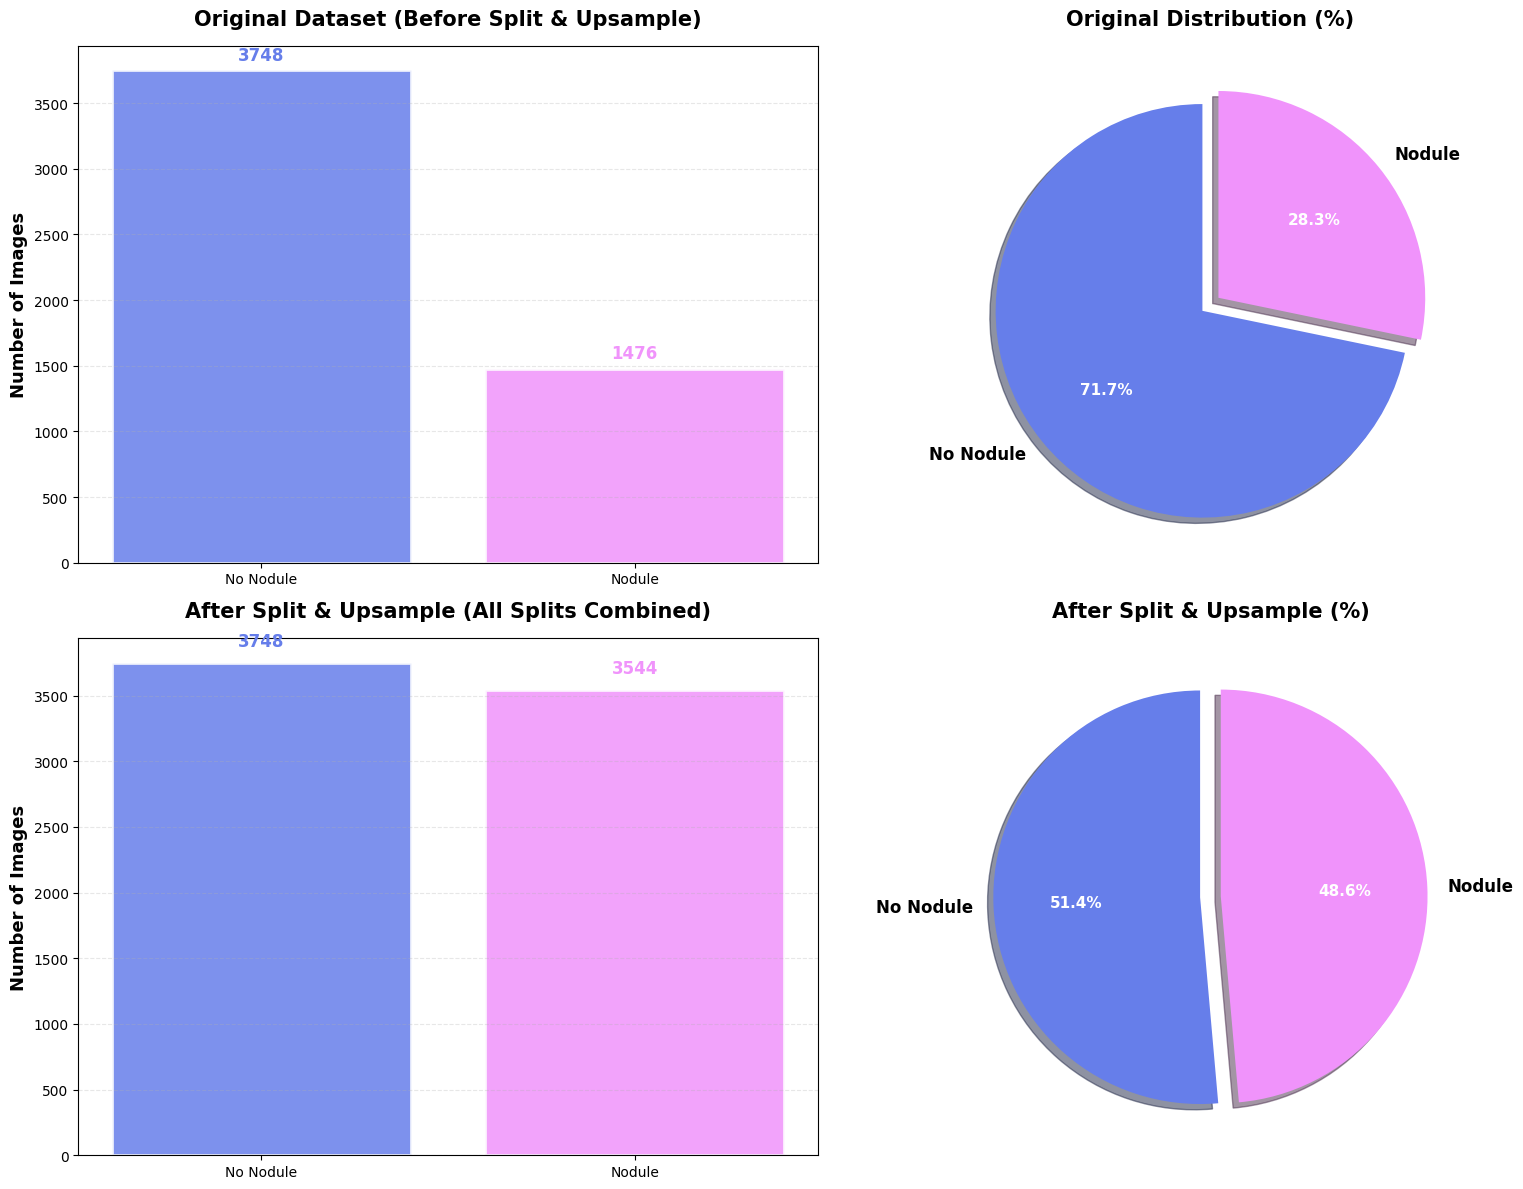


✓ Before/After comparison saved to 'before_after_split_upsample.png'


In [24]:
# %% Load Pre-Split Data

# Also load original data for before/after comparison 
original_csv_path = "./dataset_nodule21/cxr_images/proccessed_data/metadata.csv"

print("Loading metadata...")
train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)

# Try to load original data
try:
    original_df = pd.read_csv(original_csv_path)
    has_original = True
    print(f"Original dataset: {len(original_df)} samples")
except:
    has_original = False
    print("Original metadata not found, skipping before/after comparison")

print(f"Train: {len(train_df)} samples")
print(f"Val: {len(val_df)} samples")
print(f"Test: {len(test_df)} samples")

# Combine all splits for total distribution
combined_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
print(f"Total (combined): {len(combined_df)} samples")

# %% Beautiful color palette
color_negative = '#667eea'  # Soft purple
color_positive = '#f093fb'  # Soft pink
colors = [color_negative, color_positive]

# %% Figure 1: Before vs After Upsampling (if original data exists)
if has_original:
    fig1, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig1.patch.set_facecolor('white')
    
    # Original distribution - Bar
    original_counts = original_df['label'].value_counts().sort_index()
    axes[0, 0].bar(['No Nodule', 'Nodule'], original_counts.values, 
                   color=colors, alpha=0.85, edgecolor='white', linewidth=2)
    axes[0, 0].set_ylabel('Number of Images', fontsize=13, fontweight='bold')
    axes[0, 0].set_title('Original Dataset (Before Split & Upsample)', fontsize=15, fontweight='bold', pad=15)
    axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')
    axes[0, 0].set_facecolor('#ffffff')
    for i, v in enumerate(original_counts.values):
        axes[0, 0].text(i, v + 50, str(v), ha='center', va='bottom', 
                        fontsize=12, fontweight='bold', color=colors[i])
    
    # Original distribution - Pie
    wedges, texts, autotexts = axes[0, 1].pie(original_counts.values, 
                                               labels=['No Nodule', 'Nodule'], 
                                               autopct='%1.1f%%',
                                               colors=colors, 
                                               startangle=90,
                                               explode=(0.05, 0.05),
                                               shadow=True)
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(11)
    for text in texts:
        text.set_fontsize(12)
        text.set_fontweight('bold')
    axes[0, 1].set_title('Original Distribution (%)', fontsize=15, fontweight='bold', pad=15)
    
    # After split & upsample - Bar
    combined_counts = combined_df['label'].value_counts().sort_index()
    axes[1, 0].bar(['No Nodule', 'Nodule'], combined_counts.values, 
                   color=colors, alpha=0.85, edgecolor='white', linewidth=2)
    axes[1, 0].set_ylabel('Number of Images', fontsize=13, fontweight='bold')
    axes[1, 0].set_title('After Split & Upsample (All Splits Combined)', fontsize=15, fontweight='bold', pad=15)
    axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
    axes[1, 0].set_facecolor('#ffffff')
    for i, v in enumerate(combined_counts.values):
        axes[1, 0].text(i, v + 100, str(v), ha='center', va='bottom', 
                        fontsize=12, fontweight='bold', color=colors[i])
    
    # After split & upsample - Pie
    wedges, texts, autotexts = axes[1, 1].pie(combined_counts.values, 
                                               labels=['No Nodule', 'Nodule'], 
                                               autopct='%1.1f%%',
                                               colors=colors, 
                                               startangle=90,
                                               explode=(0.05, 0.05),
                                               shadow=True)
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(11)
    for text in texts:
        text.set_fontsize(12)
        text.set_fontweight('bold')
    axes[1, 1].set_title('After Split & Upsample (%)', fontsize=15, fontweight='bold', pad=15)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Before/After comparison saved to 'before_after_split_upsample.png'")

In [25]:
# Create datasets - each pointing to its own split directory
train_dataset = NoduleDataset(train_df, train_images_path, transform=train_transform)
val_dataset = NoduleDataset(val_df, val_images_path, transform=val_transform)
test_dataset = NoduleDataset(test_df, test_images_path, transform=val_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                         num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                       num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=NUM_WORKERS, pin_memory=True)

In [26]:
print("\nInitializing EfficientNet-B0 model...")
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=2)
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)


Initializing EfficientNet-B0 model...


In [27]:
# %% Training Functions
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().detach().numpy())
        
        pbar.set_postfix({'loss': running_loss/len(loader), 'acc': 100.*correct/total})
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs

In [28]:
from sklearn.metrics import f1_score, recall_score, roc_auc_score

# %% Training Loop
print("\nStarting training...")
history = {
    'train_loss': [], 'train_acc': [], 'train_auc': [], 'train_recall': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_auc': [], 'val_recall': [], 'val_f1': []
}

best_val_f1 = 0.0
best_model_path = 'best_efficientnet_nodule_model.pth'
NUM_EPOCHS = 25

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc, train_preds, train_labels, train_probs = train_epoch(
        model, train_loader, criterion, optimizer, device)
    
    # Calculate train metrics
    train_auc    = roc_auc_score(train_labels, train_probs)
    train_recall = recall_score(train_labels, train_preds, average='binary', zero_division=0)
    train_f1     = f1_score(train_labels, train_preds, average='binary', zero_division=0)
    
    # Validate
    val_loss, val_acc, val_preds, val_labels, val_probs = validate(
        model, val_loader, criterion, device)
    
    # Calculate val metrics
    val_auc    = roc_auc_score(val_labels, val_probs)
    val_recall = recall_score(val_labels, val_preds, average='binary', zero_division=0)
    val_f1     = f1_score(val_labels, val_preds, average='binary', zero_division=0)
    
    # Step scheduler
    scheduler.step()
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_auc'].append(train_auc)
    history['train_recall'].append(train_recall)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    history['val_recall'].append(val_recall)
    history['val_f1'].append(val_f1)
    
    print(f"Train — Loss: {train_loss:.4f} | Acc: {train_acc:.4f}% | AUC: {train_auc:.4f} | Recall: {train_recall:.4f} | F1: {train_f1:.4f}")
    print(f"Val   — Loss: {val_loss:.4f} | Acc: {val_acc:.4f}% | AUC: {val_auc:.4f} | Recall: {val_recall:.4f} | F1: {val_f1:.4f}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Save best model based on F1 Score
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': val_f1,
            'val_auc': val_auc,
            'val_recall': val_recall,
        }, best_model_path)
        print(f"✓ Saved best model (Val F1: {val_f1:.4f} | Val Recall: {val_recall:.4f}")

print("\nTraining completed!")


Starting training...

Epoch 1/25
--------------------------------------------------


Validation: 100%|██████████| 49/49 [00:14<00:00,  3.35it/s]


Train — Loss: 0.7041 | Acc: 81.8166% | AUC: 0.8977 | Recall: 0.8279 | F1: 0.8315
Val   — Loss: 0.4510 | Acc: 84.2711% | AUC: 0.9153 | Recall: 0.7022 | F1: 0.7198
LR: 0.000099
✓ Saved best model (Val F1: 0.7198 | Val Recall: 0.7022

Epoch 2/25
--------------------------------------------------


Validation: 100%|██████████| 49/49 [00:14<00:00,  3.35it/s]


Train — Loss: 0.3026 | Acc: 90.3231% | AUC: 0.9678 | Recall: 0.9139 | F1: 0.9110
Val   — Loss: 0.4312 | Acc: 88.4910% | AUC: 0.9379 | Recall: 0.7156 | F1: 0.7816
LR: 0.000098
✓ Saved best model (Val F1: 0.7816 | Val Recall: 0.7156

Epoch 3/25
--------------------------------------------------


...

Train — Loss: 0.0089 | Acc: 99.8253% | AUC: 0.9999 | Recall: 0.9990 | F1: 0.9984
Val   — Loss: 0.1636 | Acc: 94.1176% | AUC: 0.9897 | Recall: 0.8222 | F1: 0.8894
LR: 0.000005

Epoch 24/25
--------------------------------------------------


Validation: 100%|██████████| 49/49 [00:14<00:00,  3.35it/s]


Train — Loss: 0.0045 | Acc: 99.9476% | AUC: 1.0000 | Recall: 0.9997 | F1: 0.9995
Val   — Loss: 0.1155 | Acc: 95.3964% | AUC: 0.9907 | Recall: 0.9067 | F1: 0.9189
LR: 0.000010

Epoch 25/25
--------------------------------------------------


Validation: 100%|██████████| 49/49 [00:15<00:00,  3.26it/s]

Train — Loss: 0.0093 | Acc: 99.7031% | AUC: 0.9999 | Recall: 0.9974 | F1: 0.9973
Val   — Loss: 0.1559 | Acc: 94.6292% | AUC: 0.9897 | Recall: 0.8356 | F1: 0.8995
LR: 0.000015

Training completed!


In [29]:
# %% Load Best Model and Evaluate on Test Set
print("\nLoading best model for testing...")
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])

test_loss, test_acc, test_preds, test_labels, test_probs = validate(model, test_loader, criterion, device)

print(f"\nTest Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['No Nodule', 'Nodule'], digits=4))

# ROC AUC Score
auc = roc_auc_score(test_labels, test_probs)
print(f"\nROC AUC Score: {auc:.4f}")


Loading best model for testing...


Validation: 100%|██████████| 50/50 [00:14<00:00,  3.43it/s]


Test Results:
Test Loss: 0.1645
Test Accuracy: 94.52%

Classification Report:
              precision    recall  f1-score   support

   No Nodule     0.9549    0.9701    0.9624       568
      Nodule     0.9183    0.8802    0.8988       217

    accuracy                         0.9452       785
   macro avg     0.9366    0.9251    0.9306       785
weighted avg     0.9448    0.9452    0.9449       785


ROC AUC Score: 0.9853


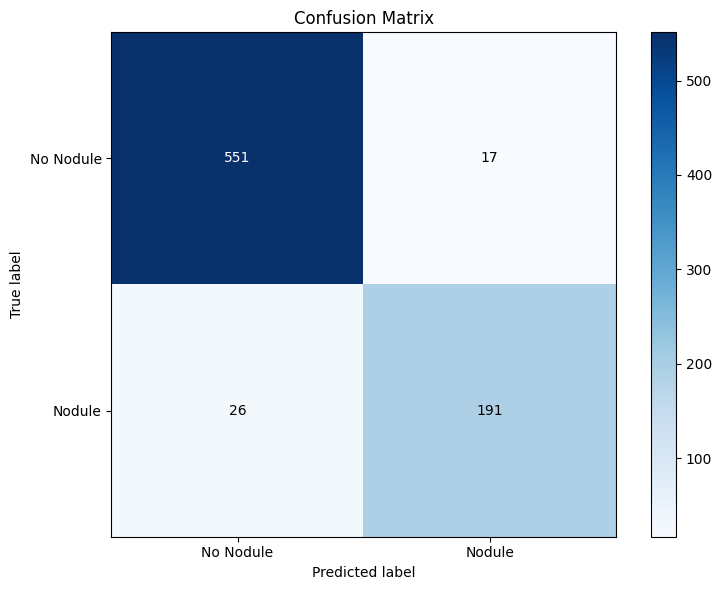


✓ Training complete! Best model saved to: best_efficientnet_nodule_model.pth


In [30]:
# %% Plot Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(test_labels, test_preds)
cm_labels = ['No Nodule', 'Nodule']


fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=['No Nodule', 'Nodule'],
       yticklabels=['No Nodule', 'Nodule'],
       title='Confusion Matrix',
       ylabel='True label',
       xlabel='Predicted label')

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

print("\n✓ Training complete! Best model saved to:", best_model_path)